In [ ]:
# Exercise 0
# load files and libraries

!pip install pymzml pyopenms pandas numpy matplotlib seaborn
import pymzml
import pandas as pd
import numpy as np

foam_file = "TJR_F1.mzML"
water_file = "TJR_UW.mzML"
blank_file = "Blank.mzML"


In [ ]:
# load spectra
foam_run = pymzml.run.Reader(foam_file)
water_run = pymzml.run.Reader(water_file)
blank_run = pymzml.run.Reader(blank_file)


In [ ]:
# extract MS1 peaks

def extract_features(run, min_intensity=1e3):
    features = []
    for spectrum in run:
        if spectrum['ms level'] == 1:
            mzs = spectrum.mz
            intensities = spectrum.i
            rts = [spectrum.scan_time_in_minutes()] * len(mzs)
            for mz, inten, rt in zip(mzs, intensities, rts):
                if inten >= min_intensity:
                    features.append({'mz_peak': mz, 'rt': rt, 'intensity': inten})
    return pd.DataFrame(features)

foam_table = extract_features(foam_run)
water_table = extract_features(water_run)
blank_table = extract_features(blank_run)

In [ ]:
# blank intensity subtraction

def subtract_blank(sample_df, blank_df, scale_factor=0.1, mz_tol=0.01):
    for idx, peak in sample_df.iterrows():
        mz_peak = peak['mz_peak']
        # Find matching peaks in blank
        match = blank_df[np.abs(blank_df['mz_peak'] - mz_peak) < mz_tol]
        if not match.empty:
            sample_df.at[idx, 'intensity'] *= scale_factor
    return sample_df

foam_table = subtract_blank(foam_table, blank_table)
water_table = subtract_blank(water_table, blank_table)


In [ ]:
# count peaks at each step

def count_peaks_stages(raw_df, filtered_df, cleaned_df, sample_name="Sample"):
    print(f"--- {sample_name} ---")
    print(f"Raw peaks: {len(raw_df)}")
    print(f"After noise filtering: {len(filtered_df)}")
    print(f"After blank subtraction/scaling: {len(cleaned_df)}\n")

# Suppose you kept the raw feature tables before filtering
foam_raw = extract_features(foam_run, min_intensity=0)  # raw, no threshold
water_raw = extract_features(water_run, min_intensity=0)

# foam_table and water_table are your cleaned tables after filtering and blank subtraction
count_peaks_stages(foam_raw, foam_table, foam_table, sample_name="Foam")
count_peaks_stages(water_raw, water_table, water_table, sample_name="Water")

--- Foam ---
Raw peaks: 1892703
After noise filtering: 55901
After blank subtraction/scaling: 55901

--- Water ---
Raw peaks: 1524088
After noise filtering: 36214
After blank subtraction/scaling: 36214



Number of peaks is indentical among filtered and blank scaling steps because of low liklihood of identical intensities between blank and sample background compounds. Compounds present in the blank are likely scaled to low intensities which will be filtered out later.

In [6]:
# Exercise 1
# normalize intensities

def normalize(df):
    df = df.copy()
    df['norm_intensity'] = df['intensity'] / df['intensity'].max()
    return df

foam_table  = normalize(foam_table)
water_table = normalize(water_table)

In [ ]:
# aligned feature matrix

import pandas as pd
import numpy as np

def align_features(foam_df, water_df, ppm_tol=10):
    rows = []

    for _, f in foam_df.iterrows():
        mz_f = f['mz_peak']
        ppm_error = np.abs(water_df['mz_peak'] - mz_f) / mz_f * 1e6
        matches = water_df[ppm_error < ppm_tol]

        if not matches.empty:
            w = matches.iloc[ppm_error[matches.index].argmin()]
            rows.append({
                'mz_aligned': mz_f,
                'foam_intensity':  f['norm_intensity'],
                'water_intensity': w['norm_intensity']
            })

    return pd.DataFrame(rows)

aligned_table = align_features(foam_table, water_table)
aligned_table.head()

In [8]:
# aligned feature table

print("Aligned feature matrix:")
display(aligned_table.head())

Aligned feature matrix:


,mz_aligned,foam_intensity,water_intensity
0,103.920291,0.001485,0.002146
1,108.021810,0.001614,0.001283
2,111.009172,0.001430,0.000809
3,115.076826,0.001220,0.000908
4,115.921165,0.002054,0.006173


In [9]:
# compute TIC from features tables

import matplotlib.pyplot as plt

def compute_tic(df):
    return df.groupby('rt')['intensity'].sum().reset_index()

foam_tic  = compute_tic(foam_table)
water_tic = compute_tic(water_table)

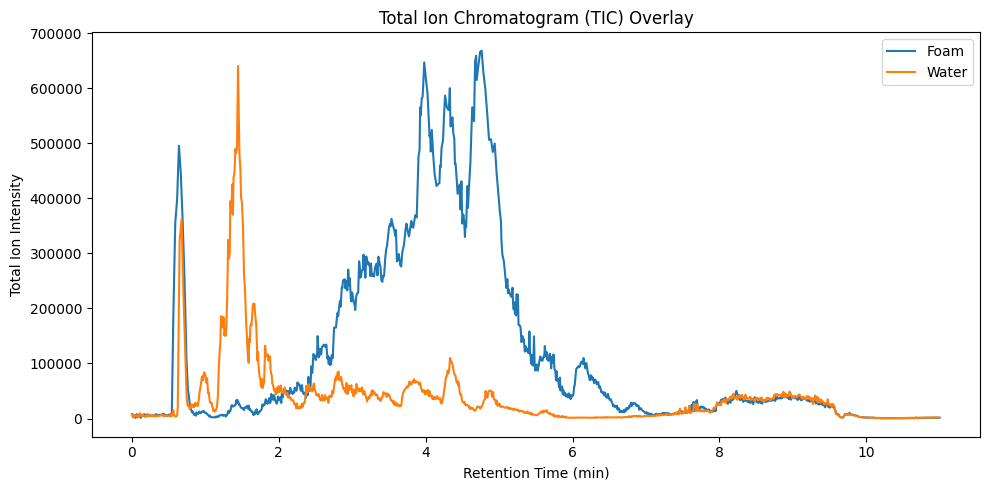

In [10]:
# plot TIC

plt.figure(figsize=(10,5))

plt.plot(foam_tic['rt'],  foam_tic['intensity'],  label='Foam')
plt.plot(water_tic['rt'], water_tic['intensity'], label='Water')

plt.xlabel("Retention Time (min)")
plt.ylabel("Total Ion Intensity")
plt.title("Total Ion Chromatogram (TIC) Overlay")
plt.legend()
plt.tight_layout()
plt.show()

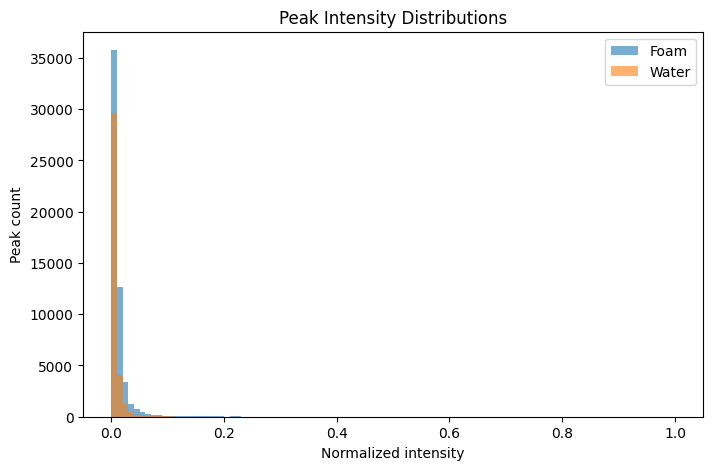

In [11]:
# peak intensity distributions

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(foam_table['norm_intensity'], bins=100, alpha=0.6, label='Foam')
plt.hist(water_table['norm_intensity'], bins=100, alpha=0.6, label='Water')
plt.xlabel("Normalized intensity")
plt.ylabel("Peak count")
plt.title("Peak Intensity Distributions")
plt.legend()
plt.show()

In [12]:
# Exercise 2
# load NORMAN list

pfas_list = pd.read_csv("PRORISKPFAS.csv", encoding='latin1')

# keep only essential columns
pfas_list = pfas_list[['Name','Monoisotopic_mass', 'Formula']]
pfas_list.info()
pfas_list.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4777 entries, 0 to 4776
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               4777 non-null   object 
 1   Monoisotopic_mass  4776 non-null   float64
 2   Formula            4776 non-null   object 
dtypes: float64(1), object(2)
memory usage: 112.1+ KB


,Name,Monoisotopic_mass,Formula
0,6:3 Fluorotelomer carboxylic acid,392.008196,C9H5F13O2
1,"(2Z)-4,4,5,5,6,6,6-Heptafluoro-2-iodohex-2-en-...",351.919510,C6H4F7IO
2,"4,4,5,5,6,6,6-heptafluoro-2-iodohex-2-en-1-ol",351.919510,C6H4F7IO
3,"Perfluoro-N,N,N',N'-tetrakis(heptafluoropropyl...",1003.942276,C18F40N2
4,Ammonium perfluoro-9-(methyl)decanoate,563.964122,C11HF21O2


In [ ]:
# exact mass matching

ppm_tol = 20

def flag_suspects(df, suspect_df, ppm_tol=20):
    df = df.copy()
    df['is_suspect'] = False

    for idx, peak in df.iterrows():
        mz = peak['mz_peak']
        ppm_error = np.abs(suspect_df['Monoisotopic_mass'] - mz) / mz * 1e6
        if (ppm_error < ppm_tol).any():
            df.at[idx, 'is_suspect'] = True

    return df

foam_table  = flag_suspects(foam_table,  pfas_list, ppm_tol)
water_table = flag_suspects(water_table, pfas_list, ppm_tol)

print("Foam suspects:",  foam_table['is_suspect'].sum())
print("Water suspects:", water_table['is_suspect'].sum())

In [14]:
# table with mass errors and intensities

def build_suspect_table(feature_df, suspect_df, mass_col, name_col, ppm_tol=20):
    rows = []

    for _, peak in feature_df.iterrows():
        mz = peak['mz_peak']
        ppm_error = np.abs(suspect_df[mass_col] - mz) / mz * 1e6
        matches = suspect_df[ppm_error < ppm_tol]

        if not matches.empty:
            best_idx = ppm_error[matches.index].argmin()
            best_match = matches.loc[matches.index[best_idx]]
            best_error = ppm_error.loc[matches.index[best_idx]]

            rows.append({
                'mz_peak': mz,
                'rt': peak['rt'],
                'intensity': peak['intensity'],
                'norm_intensity': peak['norm_intensity'],
                'suspect_name': best_match[name_col],
                'suspect_mass': best_match[mass_col],
                'ppm_error': best_error
            })

    result = pd.DataFrame(rows)
    return result.sort_values('intensity', ascending=False)

In [ ]:
# generate table

foam_suspects  = build_suspect_table(foam_table,  pfas_list,
                                     mass_col='Monoisotopic_mass',
                                     name_col='Name')

water_suspects = build_suspect_table(water_table, pfas_list,
                                     mass_col='Monoisotopic_mass',
                                     name_col='Name')

In [16]:
# preview tables

print("FOAM SUSPECTS")
display(foam_suspects.head())

print("WATER SUSPECTS")
display(water_suspects.head())

FOAM SUSPECTS


,mz_peak,rt,intensity,norm_intensity,suspect_name,suspect_mass,ppm_error
193,488.985946,0.640482,22442.439453,0.175706,"1-Heptanesulfonamide, 1,1,2,2,3,3,4,4,5,5,6,6,...",488.987972,4.143444
251,646.961525,0.666787,13633.595703,0.106740,"1-(3,3,4,4,5,5,6,6,7,7,8,8,8-Tridecafluoro-1-i...",646.965834,6.660429
146,488.986085,0.615787,13502.456055,0.105713,"1-Heptanesulfonamide, 1,1,2,2,3,3,4,4,5,5,6,6,...",488.987972,3.859273
307,359.022622,0.716660,12416.813477,0.097213,"3,3,4,4,5,5,5-Heptafluoro-1-(3-methyl-1,3-benz...",359.021482,3.174339
271,359.022558,0.691502,11090.024414,0.086826,"3,3,4,4,5,5,5-Heptafluoro-1-(3-methyl-1,3-benz...",359.021482,2.996737


WATER SUSPECTS


,mz_peak,rt,intensity,norm_intensity,suspect_name,suspect_mass,ppm_error
402,432.982398,1.667637,15881.060547,0.104993,"2,2,3,3,4,4,4-Heptafluoro-N-(nonafluorobutyl)b...",432.975928,14.942007
86,488.986052,0.650282,15057.164062,0.099546,"1-Heptanesulfonamide, 1,1,2,2,3,3,4,4,5,5,6,6,...",488.987972,3.926259
415,432.982483,1.680310,13864.270508,0.091659,"2,2,3,3,4,4,4-Heptafluoro-N-(nonafluorobutyl)b...",432.975928,15.138990
425,432.981612,1.693478,13656.047852,0.090283,"2,2,3,3,4,4,4-Heptafluoro-N-(nonafluorobutyl)b...",432.975928,13.127723
375,395.018952,1.628313,11654.076172,0.077047,"N-(1,1,2,2,3,3,4,4,4-Nonafluorobutane-1-sulfon...",395.023768,12.191824


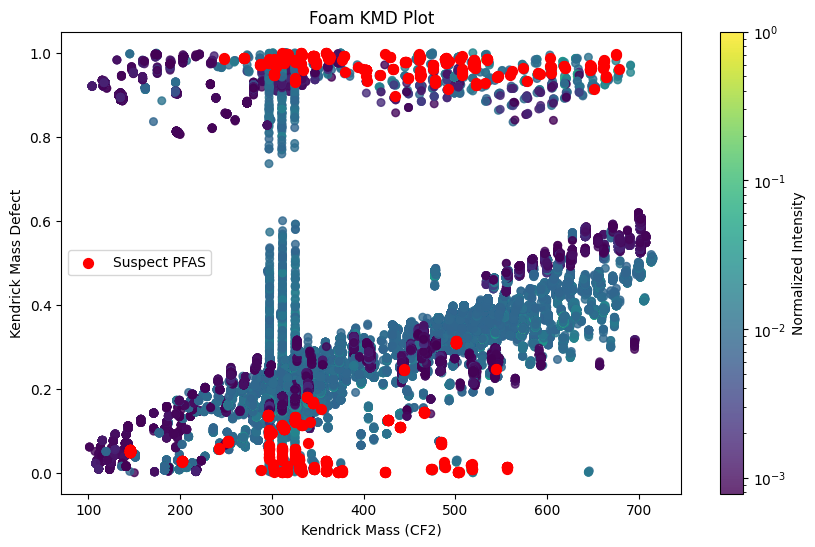

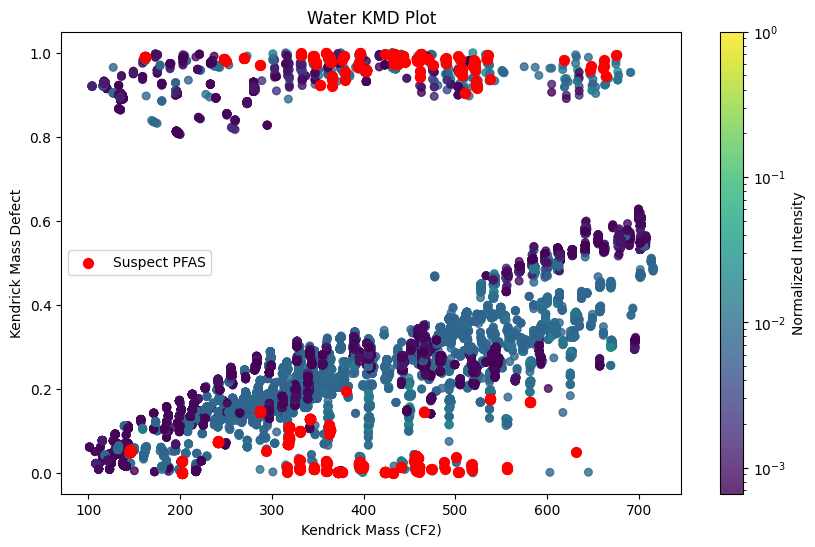

In [17]:
# Exercise 3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---------------------------
# 1️⃣ Compute Kendrick Mass & KMD
# ---------------------------
def compute_kendrick(df, base_mass=50.0):  # CF2 = 50.0
    df = df.copy()
    df['kendrick_mass'] = df['mz_peak'] * (base_mass / 50.0)  # standard CF2 base
    df['kendrick_mass_defect'] = df['kendrick_mass'] - np.floor(df['kendrick_mass'])
    return df

# ---------------------------
# 2️⃣ Detect homologous series
# ---------------------------
def detect_homologues(df, mass_tol=0.01, kmd_tol=0.005):
    """
    Find homologous series by clustering KMD values that are aligned.
    Returns list of series, each as list of mz_peaks.
    """
    df_sorted = df.sort_values('kendrick_mass')
    series_list = []
    current_series = []

    for idx, row in df_sorted.iterrows():
        if not current_series:
            current_series.append(idx)
            continue

        prev_idx = current_series[-1]
        prev_row = df_sorted.loc[prev_idx]

        if (abs(row['kendrick_mass_defect'] - prev_row['kendrick_mass_defect']) < kmd_tol and
            abs(row['kendrick_mass'] - prev_row['kendrick_mass']) < mass_tol):
            current_series.append(idx)
        else:
            if len(current_series) > 1:
                series_list.append(current_series)
            current_series = [idx]

    if len(current_series) > 1:
        series_list.append(current_series)

    return series_list

# ---------------------------
# 3️⃣ Plot KMD with suspects highlighted
# ---------------------------
def plot_kmd(df, suspect_df=None, mass_col=None, title="KMD Plot", intensity_col='norm_intensity'):
    df = compute_kendrick(df)

    plt.figure(figsize=(10,6))

    # All features (log-scaled intensity)
    sc = plt.scatter(
        df['kendrick_mass'],
        df['kendrick_mass_defect'],
        c=df[intensity_col],
        norm=LogNorm(),
        cmap='viridis',
        s=30,
        alpha=0.8
    )

    # Suspects overlay (red)
    if suspect_df is not None and mass_col is not None:
        suspects = []
        for _, peak in df.iterrows():
            mz = peak['mz_peak']
            ppm_error = np.abs(suspect_df[mass_col] - mz) / mz * 1e6
            if (ppm_error < 20).any():
                suspects.append(peak)
        if suspects:
            suspects_df = pd.DataFrame(suspects)
            plt.scatter(
                suspects_df['kendrick_mass'],
                suspects_df['kendrick_mass_defect'],
                c='red',
                s=50,
                label='Suspect PFAS'
            )

    plt.xlabel("Kendrick Mass (CF2)")
    plt.ylabel("Kendrick Mass Defect")
    plt.title(title)
    plt.colorbar(sc, label="Normalized Intensity")
    if suspect_df is not None:
        plt.legend()
    plt.show()

# ---------------------------
# 4️⃣ Output homologous series table
# ---------------------------
def build_homologue_table(df, series_list):
    records = []
    for i, series in enumerate(series_list, start=1):
        for idx in series:
            row = df.loc[idx].copy()
            row['series_id'] = i
            records.append(row)
    return pd.DataFrame(records)

# ---------------------------
# 5️⃣ Example: Foam
# ---------------------------
foam_kmd = compute_kendrick(foam_table)
foam_series = detect_homologues(foam_kmd)
foam_homologue_table = build_homologue_table(foam_kmd, foam_series)

plot_kmd(foam_table, suspect_df=pfas_list, mass_col='Monoisotopic_mass', title="Foam KMD Plot")

# ---------------------------
# 6️⃣ Example: Water
# ---------------------------
water_kmd = compute_kendrick(water_table)
water_series = detect_homologues(water_kmd)
water_homologue_table = build_homologue_table(water_kmd, water_series)

plot_kmd(water_table, suspect_df=pfas_list, mass_col='Monoisotopic_mass', title="Water KMD Plot")

In [18]:
# display table
from IPython.display import display

print("Foam Homologous Series Table (first 10 rows)")
display(foam_homologue_table.head(10))

print("Water Homologous Series Table (first 10 rows)")
display(water_homologue_table.head(10))

Foam Homologous Series Table (first 10 rows)


,mz_peak,rt,intensity,norm_intensity,is_suspect,kendrick_mass,kendrick_mass_defect,series_id
1600,101.061126,0.397992,113.210925,0.000886,False,101.061126,0.061126,1
1526,101.061220,0.383613,102.420618,0.000802,False,101.061220,0.061220,1
1148,101.061262,0.299995,103.097229,0.000807,False,101.061262,0.061262,1
1754,103.920212,0.434312,158.607922,0.001242,False,103.920212,0.920212,2
92,103.920269,0.027628,180.357446,0.001412,False,103.920269,0.920269,2
0,103.920291,0.005007,189.645166,0.001485,False,103.920291,0.920291,2
39,103.920316,0.012157,111.881714,0.000876,False,103.920316,0.920316,2
519,103.920353,0.156778,227.808691,0.001784,False,103.920353,0.920353,2
409,103.920392,0.126950,225.340918,0.001764,False,103.920392,0.920392,2
1320,103.920399,0.338127,112.690674,0.000882,False,103.920399,0.920399,2


Water Homologous Series Table (first 10 rows)


,mz_peak,rt,intensity,norm_intensity,is_suspect,kendrick_mass,kendrick_mass_defect,series_id
1667,101.060962,0.511438,103.755664,0.000686,False,101.060962,0.060962,1
1558,101.060988,0.480440,104.061523,0.000688,False,101.060988,0.060988,1
825,101.061083,0.272273,117.978455,0.000780,False,101.061083,0.061083,1
1694,101.061196,0.518630,120.110742,0.000794,False,101.061196,0.061196,1
1325,101.061549,0.418120,115.692212,0.000765,False,101.061549,0.061549,1
1442,101.061549,0.449438,104.810107,0.000693,False,101.061549,0.061549,1
210,103.920152,0.081438,104.889185,0.000693,False,103.920152,0.920152,2
222,103.920214,0.088620,369.734155,0.002444,False,103.920214,0.920214,2
142,103.920252,0.057645,356.281812,0.002355,False,103.920252,0.920252,2
31,103.920294,0.020613,324.584619,0.002146,False,103.920294,0.920294,2


In [ ]:
# Exercise 4
# imports

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [20]:
# subset aligned tables

def match_mz(feature_mz, suspect_mz_list, tol_ppm=20):
    """Return boolean array of features matching any suspect m/z within tol_ppm."""
    matches = np.zeros_like(feature_mz, dtype=bool)
    for suspect in suspect_mz_list:
        delta = np.abs(feature_mz - suspect)
        ppm_error = delta / suspect * 1e6
        matches |= ppm_error <= tol_ppm
    return matches
# Convert to numpy arrays
feature_mz = aligned_table['mz_aligned'].to_numpy()
foam_suspect_mz = foam_suspects['mz_peak'].to_numpy()
water_suspect_mz = water_suspects['mz_peak'].to_numpy()

# Boolean masks
foam_mask = match_mz(feature_mz, foam_suspect_mz)
water_mask = match_mz(feature_mz, water_suspect_mz)

# Subset aligned_table
foam_features = aligned_table[foam_mask]
water_features = aligned_table[water_mask]

# Combine both
pfas_features = pd.concat([foam_features, water_features]).drop_duplicates()


In [21]:
# log transform

# Automatically detect numeric columns (sample intensities)
numeric_cols = pfas_features.select_dtypes(include=np.number).columns.tolist()
# Exclude mz_aligned if present
numeric_cols = [c for c in numeric_cols if c != 'mz_aligned']

pfas_log = pfas_features.copy()
pfas_log[numeric_cols] = np.log10(pfas_log[numeric_cols] + 1)


In [25]:
# top N feature filtering

top_n = 50

# Compute max intensity across sample columns
pfas_log['max_intensity'] = pfas_log[numeric_cols].max(axis=1)

# Select top-N features by intensity, but keep all columns including 'suspect_name' and 'mz_aligned'
top_features = pfas_log.nlargest(top_n, 'max_intensity').copy()

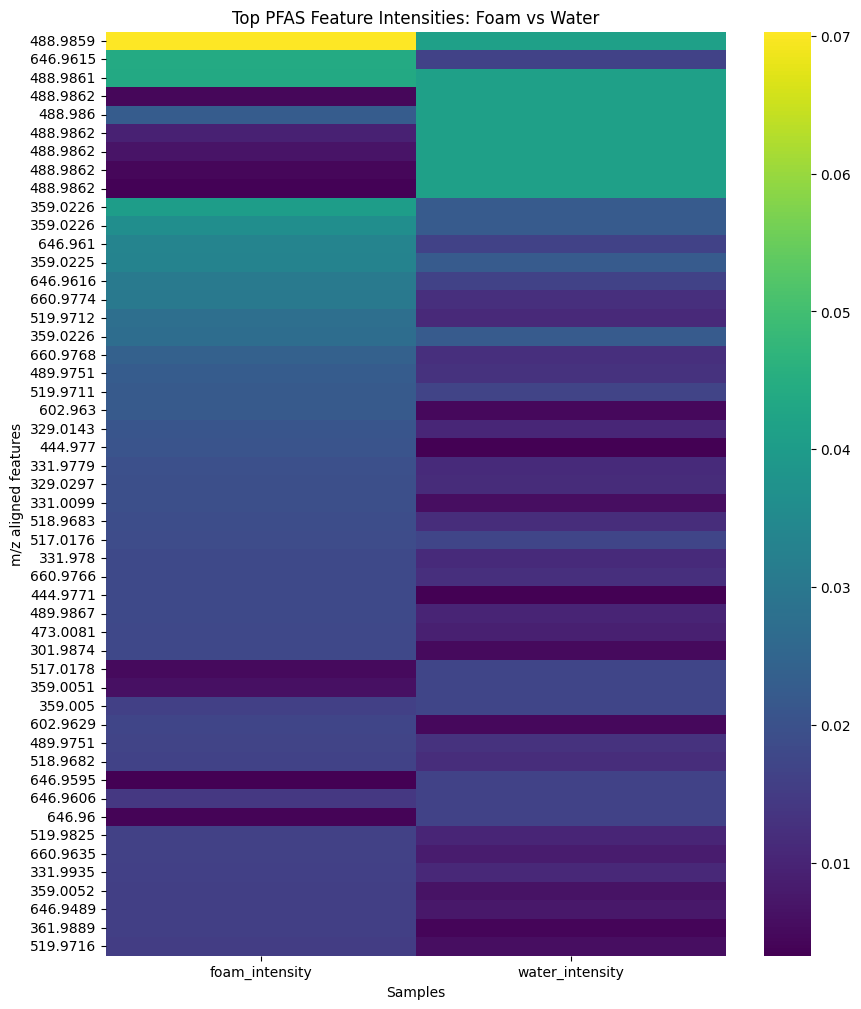

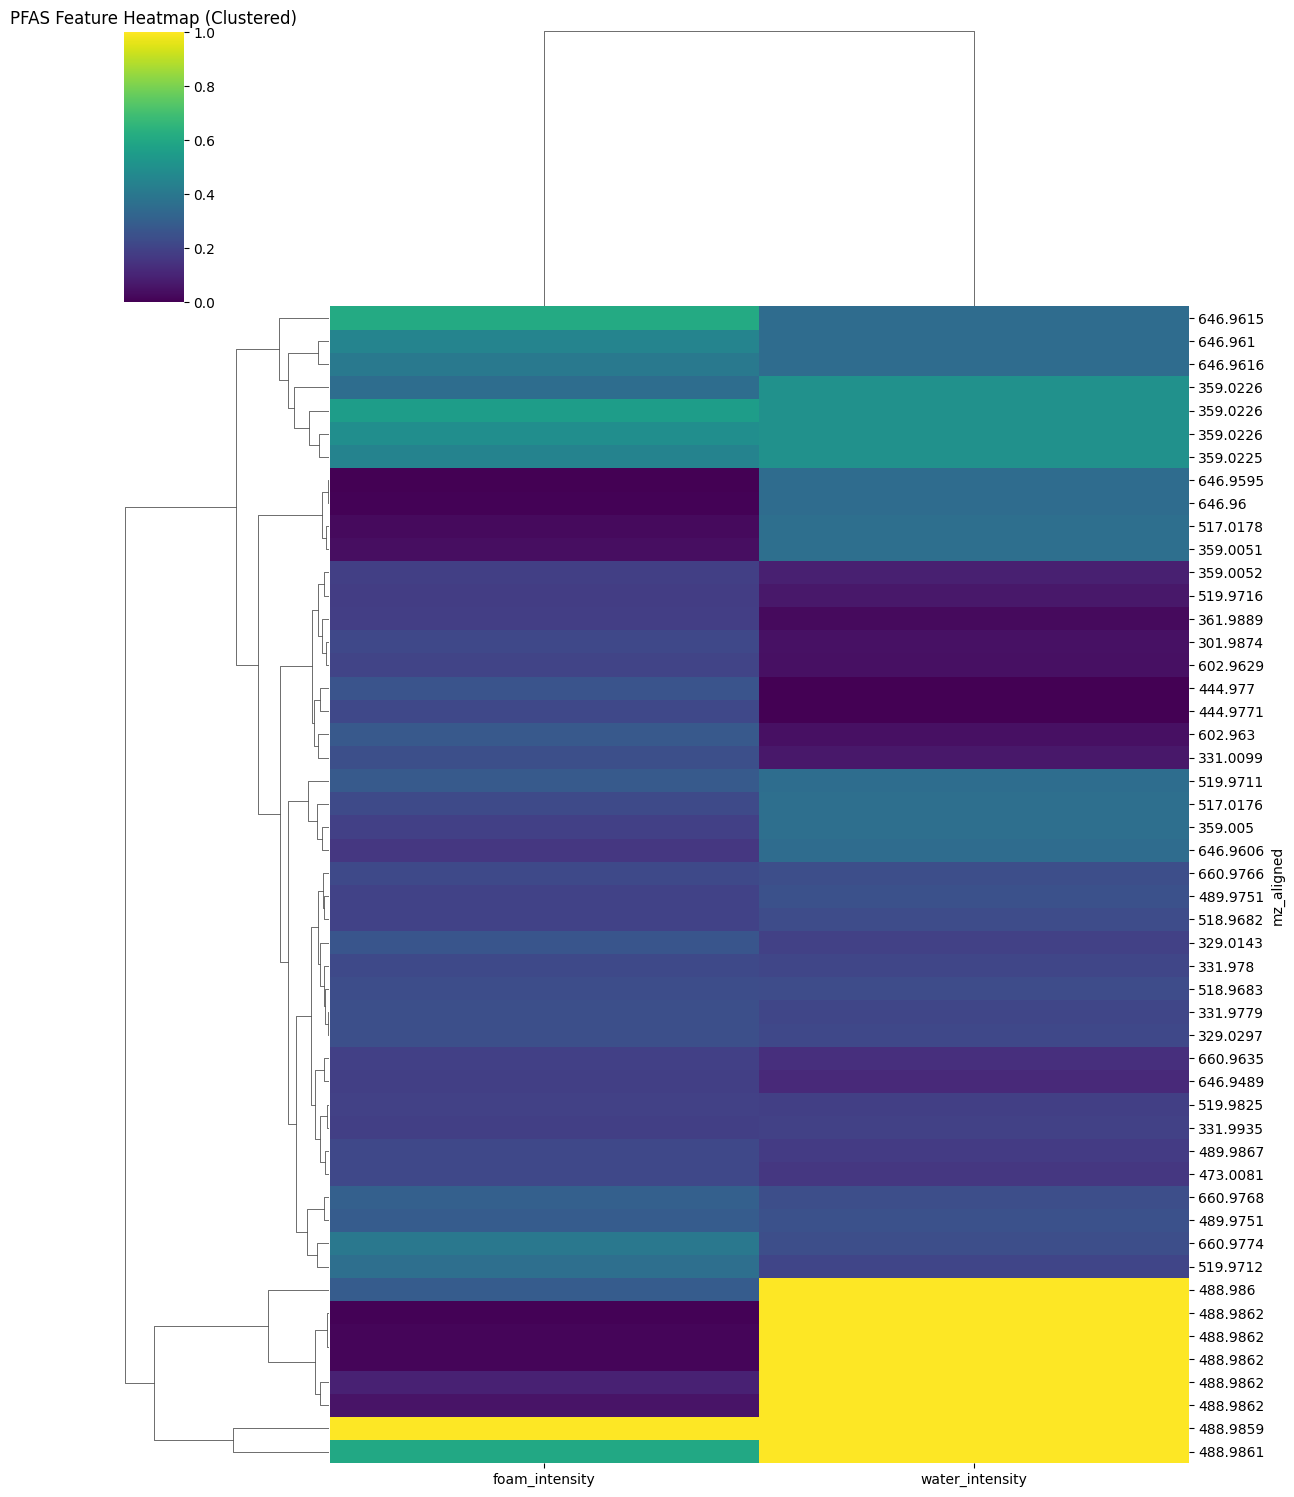

In [27]:

# Use mz_aligned as row labels
top_features.index = top_features['mz_aligned'].round(4).astype(str)

# Plot the heatmap
plt.figure(figsize=(10,12))
sns.heatmap(top_features[numeric_cols], cmap='viridis', yticklabels=True, xticklabels=True)
plt.title('Top PFAS Feature Intensities: Foam vs Water')
plt.ylabel('m/z aligned features')
plt.xlabel('Samples')
plt.show()

# Optional clustered heatmap
sns.clustermap(top_features[numeric_cols],
               cmap='viridis',
               standard_scale=1,
               figsize=(12,15))
plt.title('PFAS Feature Heatmap (Clustered)')
plt.show()